<a href="https://colab.research.google.com/github/Gise08/Aprendizaje-Autom-tico/blob/main/AA_GiselaGarcia_Semana3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargamos el dataset desde la fuente directa
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv'
df = pd.read_csv(url)

# Realizamos la conversión de categorías a números
mapeo = {'usa': 1, 'europe': 2, 'japan': 3}
df['origin'] = df['origin'].map(mapeo)

# Verificamos la estructura inicial
df.head()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino


En esta etapa cargamos el conjunto de datos Automobile.csv en un DataFrame de Pandas. Realizamos una transformación en la columna "origin" convirtiendo los valores categóricos (usa, europe, japan) en numéricos (1, 2, 3) para permitir el análisis estadístico y visual posterior

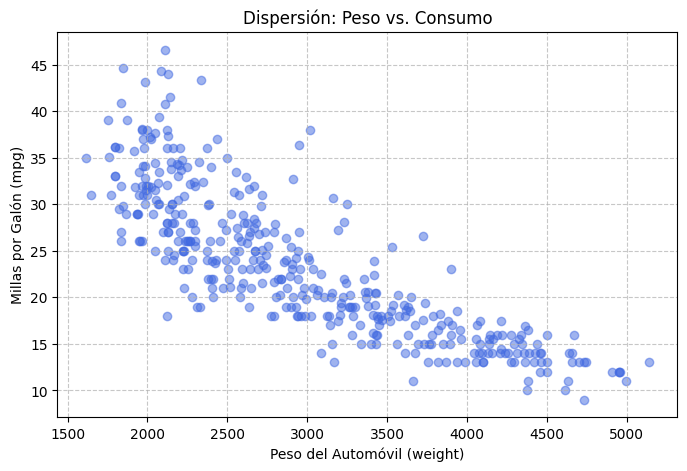

In [2]:
#Relación entre Consumo y Peso
plt.figure(figsize=(8, 5))
plt.scatter(df['weight'], df['mpg'], alpha=0.5, color='royalblue')
plt.title('Dispersión: Peso vs. Consumo')
plt.xlabel('Peso del Automóvil (weight)')
plt.ylabel('Millas por Galón (mpg)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

El gráfico de dispersión nos permite visualizar la relación entre dos variables numéricas. Aquí se observa una correlación negativa clara, a mayor peso del vehículo, menor es su eficiencia de combustible (mpg)

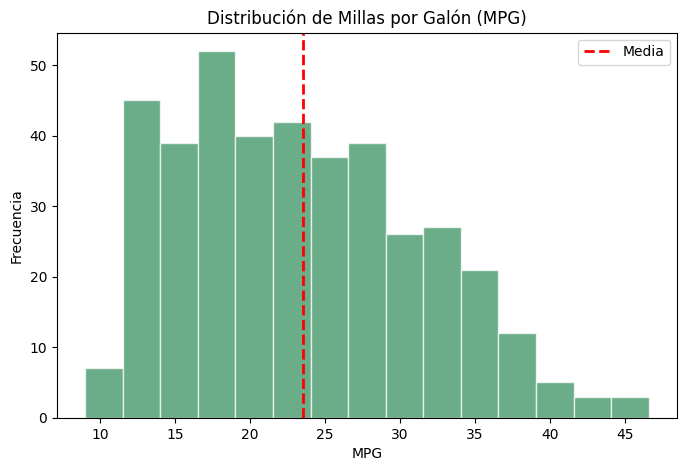

In [6]:
#Distribución del Consumo (MPG)
plt.figure(figsize=(8, 5))
plt.hist(df['mpg'], bins=15, color='seagreen', edgecolor='white', alpha=0.7)
plt.axvline(df['mpg'].mean(), color='red', linestyle='dashed', linewidth=2, label='Media')
plt.title('Distribución de Millas por Galón (MPG)')
plt.xlabel('MPG')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

El histograma muestra una distribución con un claro sesgo a la derecha (asimetría positiva). La mayoría de los vehículos se concentran en valores bajos y medios de eficiencia, mientras que unos pocos modelos alcanzan rendimientos altos, lo que genera esa "cola" hacia los valores superiores

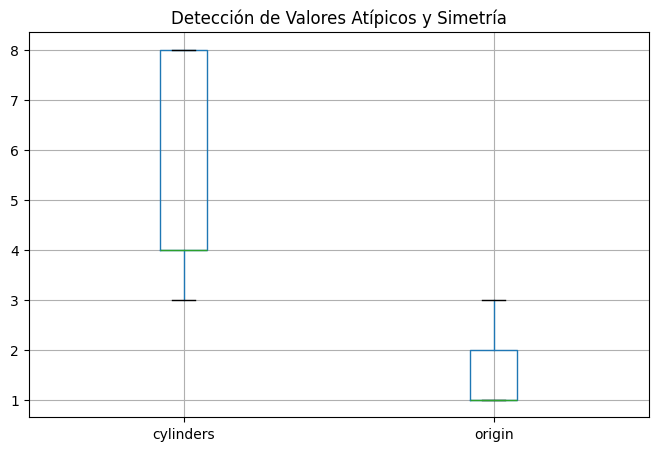

In [7]:
#Detección de Anomalías (Outliers)
plt.figure(figsize=(8, 5))
df.boxplot(column=['cylinders', 'origin'])
plt.title('Detección de Valores Atípicos y Simetría')
plt.show()

El diagrama de caja o boxplot es fundamental para identificar posibles outliers o valores atípicos.En la variable "cylinders", se observa una caja amplia con un brazo inferior extendido, indicando mayor variabilidad en los motores de pocos cilindros. En cuanto al "origin", la longitud del brazo superior y su relación con la caja sugieren que el 50% de los datos corresponden a Europa (2) y el 25% a Japón (3), confirmando una distribución desigual en la muestra



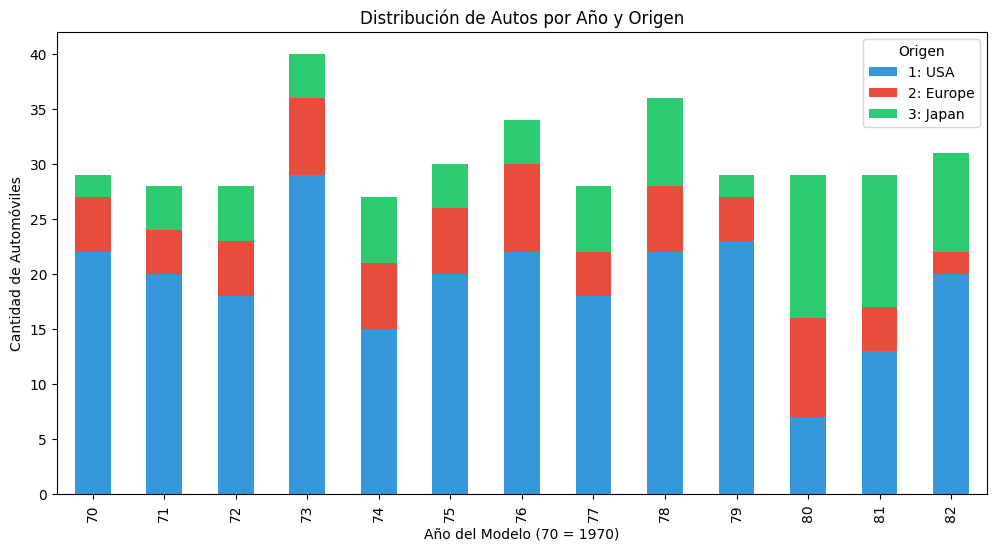

In [8]:
#Distribución por Año y Origen
distribucion = df.groupby(['model_year', 'origin']).size().unstack()
distribucion.plot(kind='bar', figsize=(12, 6), stacked=True, color=['#3498db', '#e74c3c', '#2ecc71'])
plt.title('Distribución de Autos por Año y Origen')
plt.xlabel('Año del Modelo (70 = 1970)')
plt.ylabel('Cantidad de Automóviles')
plt.legend(title='Origen', labels=['1: USA', '2: Europe', '3: Japan'])
plt.show()

Este gráfico de barras muestra la distribución de automóviles según su año de modelo y origen. Podemos observar cómo el origen Asia (3: Japan) gana terreno frente a la producción de USA (1) y Europe (2) a medida que avanzan los años 70.